# **슬라이싱**

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import os

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 경로 및 파일 설정
# 파일명이 '모투데이터.xlsx'라고 가정합니다. (만약 확장자가 다르면 수정해주세요)
file_name = "모투데이터.xlsx"
base_path = "/content/drive/MyDrive/"
file_path = os.path.join(base_path, file_name)
output_file = os.path.join(base_path, "sliced_A_group_data.xlsx")

# 3. 슬라이싱 범위 설정 (엑셀 3688행 ~ 3736행)
start_row = 3687  # 인덱스는 0부터이므로 3688행은 3687
end_row = 3736
nrows = end_row - start_row + 1

sheets = ['거래량', '수정시가', '수정고가', '수정저가', '수정주가', '시가총액']
column_mapping = {
    '수정시가': 'Adj_Open', '수정고가': 'Adj_High', '수정저가': 'Adj_Low',
    '수정주가': 'Adj_Close', '거래량': 'Volume', '시가총액': 'Market_Cap'
}

master_df = None

print(f"🚀 '{file_name}' 분석 및 슬라이싱 시작...")

if not os.path.exists(file_path):
    print(f"⚠️ 에러: 드라이브 경로에 '{file_name}' 파일이 없습니다. 파일명을 다시 확인해주세요!")
    # 파일 목록을 출력해 확인을 돕습니다.
    print("현재 내 드라이브 파일 목록:", [f for f in os.listdir(base_path) if '모투' in f])
else:
    for sheet in sheets:
        try:
            # 특정 행 범위만 타격해서 읽기 (메모리 효율적)
            df_sheet = pd.read_excel(file_path, sheet_name=sheet,
                                     skiprows=range(1, start_row),
                                     nrows=nrows)

            date_col = df_sheet.columns[0]

            # 가로(Wide) 데이터를 세로(Long) 데이터로 변환
            melted = df_sheet.melt(id_vars=[date_col], var_name='Code', value_name=column_mapping[sheet])

            if master_df is None:
                master_df = melted
            else:
                master_df = pd.merge(master_df, melted, on=[date_col, 'Code'], how='outer')

            print(f"✅ {sheet} 시트 완료")
        except Exception as e:
            print(f"❌ {sheet} 시트 처리 중 오류: {e}")

    # 4. 데이터 정제 및 저장
    if master_df is not None:
        master_df.rename(columns={master_df.columns[0]: 'Date'}, inplace=True)
        master_df['Date'] = pd.to_datetime(master_df['Date'])
        master_df.dropna(subset=['Adj_Close'], inplace=True)

        print("-" * 30)
        print(f"💾 결과 저장 중: {output_file}")
        master_df.to_excel(output_file, index=False)
        print("✨ 슬라이싱 및 통합 성공! 이제 드라이브에서 'sliced_A_group_data.xlsx'를 확인하세요.")
    else:
        print("😭 데이터 병합에 실패했습니다.")

Mounted at /content/drive
🚀 '모투데이터.xlsx' 분석 및 슬라이싱 시작...
✅ 거래량 시트 완료
✅ 수정시가 시트 완료
✅ 수정고가 시트 완료
✅ 수정저가 시트 완료
✅ 수정주가 시트 완료
✅ 시가총액 시트 완료
------------------------------
💾 결과 저장 중: /content/drive/MyDrive/sliced_A_group_data.xlsx
✨ 슬라이싱 및 통합 성공! 이제 드라이브에서 'sliced_A_group_data.xlsx'를 확인하세요.


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import os

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 경로 설정
file_name = "모투데이터.xlsx"
base_path = "/content/drive/MyDrive/"
file_path = os.path.join(base_path, file_name)
output_file = os.path.join(base_path, "sliced_A_group_data.xlsx")

# 3. 슬라이싱 범위 설정
# 엑셀 1행(헤더)은 유지하고, 2행~3687행까지를 모두 건너뜁니다.
# 그러면 3688행이 데이터의 첫 번째 행이 됩니다.
start_row = 3688
end_row = 3736
nrows = end_row - start_row + 1

sheets = ['거래량', '수정시가', '수정고가', '수정저가', '수정주가', '시가총액']
column_mapping = {
    '수정시가': 'Adj_Open', '수정고가': 'Adj_High', '수정저가': 'Adj_Low',
    '수정주가': 'Adj_Close', '거래량': 'Volume', '시가총액': 'Market_Cap'
}

master_df = None

print(f"🚀 '{file_name}' 맞춤형 슬라이싱 시작...")

if not os.path.exists(file_path):
    print(f"⚠️ 에러: 드라이브에 '{file_name}'이 없습니다.")
else:
    for sheet in sheets:
        try:
            # [핵심] header=0으로 1행(Symbol)을 컬럼명으로 잡고,
            # skiprows로 2행(index 1)부터 3687행(index 3686)까지 다 건너뜁니다.
            df_sheet = pd.read_excel(file_path, sheet_name=sheet,
                                     header=0,
                                     skiprows=range(1, start_row - 1),
                                     nrows=nrows)

            # 첫 번째 열(A열)의 이름을 'Date'로 강제 지정
            df_sheet.rename(columns={df_sheet.columns[0]: 'Date'}, inplace=True)

            # Wide -> Long 변환
            melted = df_sheet.melt(id_vars=['Date'], var_name='Code', value_name=column_mapping[sheet])

            if master_df is None:
                master_df = melted
            else:
                master_df = pd.merge(master_df, melted, on=['Date', 'Code'], how='outer')

            print(f"✅ {sheet} 시트 완료 (데이터 행 수: {len(df_sheet)})")
        except Exception as e:
            print(f"❌ {sheet} 시트 오류: {e}")

    # 4. 최종 정제 및 저장
    if master_df is not None:
        # 날짜 포맷 변환 및 정렬
        master_df['Date'] = pd.to_datetime(master_df['Date'])
        master_df = master_df.sort_values(['Date', 'Code'])

        # 수치 데이터가 하나도 없는 행 제거
        master_df.dropna(subset=['Adj_Close'], inplace=True)

        master_df.to_excel(output_file, index=False)
        print("-" * 30)
        print(f"✨ 슬라이싱 완료! 저장 경로: {output_file}")
        print(master_df.head())
    else:
        print("😭 데이터 생성 실패")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 '모투데이터.xlsx' 맞춤형 슬라이싱 시작...
✅ 거래량 시트 완료 (데이터 행 수: 49)
✅ 수정시가 시트 완료 (데이터 행 수: 49)
✅ 수정고가 시트 완료 (데이터 행 수: 49)
✅ 수정저가 시트 완료 (데이터 행 수: 49)
✅ 수정주가 시트 완료 (데이터 행 수: 49)
✅ 시가총액 시트 완료 (데이터 행 수: 49)
------------------------------
✨ 슬라이싱 완료! 저장 경로: /content/drive/MyDrive/sliced_A_group_data.xlsx
        Date     Code    Volume  Adj_Open  Adj_High  Adj_Low  Adj_Close  \
0 2026-01-31  A000020   77156.0    6130.0    6130.0   6030.0     6070.0   
1 2026-01-31  A000040  181166.0     447.0     466.0    422.0      430.0   
2 2026-01-31  A000050  781289.0    8940.0    9520.0   8740.0     9350.0   
3 2026-01-31  A000070   29490.0   60400.0   61800.0  59800.0    60800.0   
4 2026-01-31  A000080  170223.0   17660.0   17770.0  17560.0    17600.0   

   Market_Cap  
0    169544.0  
1     37141.0  
2    256333.0  
3    472002.0  
4   1234352.0  


In [ ]:
import pandas as pd
from google.colab import drive
import os

# 1. 구글 드라이브 마운트 (이미 되어 있다면 패스함)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. 경로 설정
file_name = "모투데이터.xlsx"
base_path = "/content/drive/MyDrive/"
file_path = os.path.join(base_path, file_name)
output_file = os.path.join(base_path, "모투데이터_슬라이싱완료.xlsx")

# 3. 설정 정보
sheets = ['거래량', '수정시가', '수정고가', '수정저가', '수정주가', '시가총액']

print(f"🚀 '{file_name}' 슬라이싱 시작 (오류 수정 버전)...")

# 엔진을 'openpyxl'로 변경 (코랩 기본 내장)
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    for sheet in sheets:
        try:
            # [A] 상위 4행 헤더 읽기
            header_df = pd.read_excel(file_path, sheet_name=sheet, nrows=4, header=None)

            # [B] 데이터 슬라이싱 (3688행 ~ 3736행)
            # 3687행을 건너뛰고 그 다음부터 49행을 읽음
            data_df = pd.read_excel(file_path, sheet_name=sheet,
                                    skiprows=3687,
                                    nrows=49,
                                    header=None)

            # [C] 결합
            final_sheet_df = pd.concat([header_df, data_df], axis=0, ignore_index=True)

            # [D] 저장
            final_sheet_df.to_excel(writer, sheet_name=sheet, index=False, header=False)

            print(f"✅ '{sheet}' 시트 완료")

        except Exception as e:
            print(f"❌ '{sheet}' 시트 처리 중 오류: {e}")

print("-" * 30)
print(f"✨ 작업 완료! 드라이브에서 '{output_file}' 파일을 확인하세요.")

🚀 '모투데이터.xlsx' 슬라이싱 시작 (오류 수정 버전)...
✅ '거래량' 시트 완료
✅ '수정시가' 시트 완료
✅ '수정고가' 시트 완료
✅ '수정저가' 시트 완료
✅ '수정주가' 시트 완료
✅ '시가총액' 시트 완료
------------------------------
✨ 작업 완료! 드라이브에서 '/content/drive/MyDrive/모투데이터_슬라이싱완료.xlsx' 파일을 확인하세요.


# **1차 스크리닝**

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
import os

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 경로 및 파일 설정
base_path = "/content/drive/MyDrive/"
input_file = os.path.join(base_path, "모투데이터_슬라이싱완료.xlsx")
output_file = os.path.join(base_path, "screening_results_A_group.xlsx")

# 3. 데이터 로드 및 전처리 함수
def load_all_sheets(file_path):
    sheets = ['거래량', '수정시가', '수정고가', '수정저가', '수정주가', '시가총액']
    column_mapping = {
        '수정시가': 'open', '수정고가': 'high', '수정저가': 'low',
        '수정주가': 'close', '거래량': 'volume', '시가총액': 'mcap'
    }

    master_df = None

    for sheet in sheets:
        # 1행(Symbol)을 헤더로 사용, 2~4행은 무시하고 5행부터 데이터 읽기
        df = pd.read_excel(file_path, sheet_name=sheet, header=0, skiprows=[1, 2, 3])
        df.rename(columns={df.columns[0]: 'Date'}, inplace=True)

        # Wide -> Long 변환
        melted = df.melt(id_vars=['Date'], var_name='Code', value_name=column_mapping[sheet])
        melted['Date'] = pd.to_datetime(melted['Date'])

        if master_df is None:
            master_df = melted
        else:
            master_df = pd.merge(master_df, melted, on=['Date', 'Code'], how='outer')

    return master_df

# 4. 스크리닝 로직 실행
print("🚀 데이터 로드 및 지표 계산 시작...")
df = load_all_sheets(input_file)

# 수치형 변환 및 정렬
numeric_cols = ['open', 'high', 'low', 'close', 'volume', 'mcap']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['close']).sort_values(['Code', 'Date'])

results = []
# 종목별 루프
for code, group in df.groupby('Code'):
    if len(group) < 20: continue # 지표 계산을 위한 최소 데이터 확인

    # 지표 계산
    # A. 5일 이동평균선 (MA5)
    group['ma5'] = group['close'].rolling(5).mean()

    # B. 거래대금 (Volume * Close) 및 5일 평균
    group['trd_val'] = group['volume'] * group['close']
    group['trd_val_ma5'] = group['trd_val'].rolling(5).mean()

    # C. Slow Stochastic (14, 3, 3)
    low_14 = group['low'].rolling(14).min()
    high_14 = group['high'].rolling(14).max()
    fast_k = 100 * ((group['close'] - low_14) / (high_14 - low_14).replace(0, np.nan))
    group['slow_k'] = fast_k.rolling(3).mean()
    group['slow_d'] = group['slow_k'].rolling(3).mean()

    # 최신 데이터 추출 (3월 20일 기준)
    today = group.iloc[-1]
    yesterday = group.iloc[-2]

    # --- 스크리닝 조건 ---
    # 1. 시가총액 1,000억원 이상 (단위: 백만원 -> 100,000 이상)
    cond_mcap = today['mcap'] >= 100000

    # 2. 최근 5일 평균 거래대금 10억원 이상 (단위: 원 기준 -> 1,000,000,000)
    # 만약 거래량이 주식 수라면 수정주가와 곱한 값이 원 단위입니다.
    cond_vol = today['trd_val_ma5'] >= 1000000000

    # 3. 과매도권 진입 후 탈출 시도 (최근 5일 내 %K가 25 이하인 적이 있음)
    cond_oversold = (group['slow_k'].tail(5) <= 25).any()

    # 4. 스토캐스틱 골든크로스 (K가 D를 상향 돌파)
    cond_gc = (yesterday['slow_k'] < yesterday['slow_d']) and (today['slow_k'] > today['slow_d'])

    # 5. 가격이 5일 이평선 돌파
    cond_ma_break = today['close'] > today['ma5']

    if cond_mcap and cond_vol and cond_gc and cond_ma_break and cond_oversold:
        results.append({
            'Date': today['Date'].strftime('%Y-%m-%d'),
            'Code': code,
            'Price': today['close'],
            'MA5': round(today['ma5'], 2),
            'Slow_K': round(today['slow_k'], 2),
            'Slow_D': round(today['slow_d'], 2),
            'MarketCap(M)': int(today['mcap']),
            'AvgTrdVal_5D': int(today['trd_val_ma5'])
        })

# 5. 결과 정리 및 저장
res_df = pd.DataFrame(results)
if not res_df.empty:
    # 시가총액 순으로 정렬하여 상위 20개 추출
    final_selection = res_df.sort_values('MarketCap(M)', ascending=False).head(20)
    final_selection.to_excel(output_file, index=False)
    print(f"✨ 스크리닝 완료! {len(final_selection)}개 종목이 추출되었습니다.")
    print(f"📁 저장 경로: {output_file}")
    print(final_selection)
else:
    print("❌ 조건에 맞는 종목이 없습니다.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 데이터 로드 및 지표 계산 시작...
✨ 스크리닝 완료! 2개 종목이 추출되었습니다.
📁 저장 경로: /content/drive/MyDrive/screening_results_A_group.xlsx
         Date     Code    Price      MA5  Slow_K  Slow_D  MarketCap(M)  \
1  2026-03-20  A271940  17500.0  16820.0   22.34   22.31        635481   
0  2026-03-20  A117580  11140.0  10498.0   17.49   13.29        306350   

   AvgTrdVal_5D  
1    2166473792  
0   47481417904  


In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
import os

# 1. 구글 드라이브 마운트
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. 경로 설정
base_path = "/content/drive/MyDrive/"
input_file = os.path.join(base_path, "모투데이터_슬라이싱완료.xlsx")
output_file = os.path.join(base_path, "screening_results_A_group_v2.xlsx")

# 3. 데이터 로드 (이전 로직 동일)
def load_all_sheets(file_path):
    sheets = ['거래량', '수정시가', '수정고가', '수정저가', '수정주가', '시가총액']
    column_mapping = {'수정시가': 'open', '수정고가': 'high', '수정저가': 'low', '수정주가': 'close', '거래량': 'volume', '시가총액': 'mcap'}
    master_df = None
    for sheet in sheets:
        df = pd.read_excel(file_path, sheet_name=sheet, header=0, skiprows=[1, 2, 3])
        df.rename(columns={df.columns[0]: 'Date'}, inplace=True)
        melted = df.melt(id_vars=['Date'], var_name='Code', value_name=column_mapping[sheet])
        melted['Date'] = pd.to_datetime(melted['Date'])
        if master_df is None: master_df = melted
        else: master_df = pd.merge(master_df, melted, on=['Date', 'Code'], how='outer')
    return master_df

print("🚀 완화된 조건으로 스크리닝 시작...")
df = load_all_sheets(input_file)
numeric_cols = ['open', 'high', 'low', 'close', 'volume', 'mcap']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['close']).sort_values(['Code', 'Date'])

results = []
for code, group in df.groupby('Code'):
    if len(group) < 20: continue

    # 지표 계산
    group['ma5'] = group['close'].rolling(5).mean()
    group['ma20'] = group['close'].rolling(20).mean() # 이격도 계산용 추가
    group['trd_val'] = group['volume'] * group['close']
    group['trd_val_ma5'] = group['trd_val'].rolling(5).mean()

    # Stochastic (14, 3, 3)
    low_14 = group['low'].rolling(14).min()
    high_14 = group['high'].rolling(14).max()
    fast_k = 100 * ((group['close'] - low_14) / (high_14 - low_14).replace(0, np.nan))
    group['slow_k'] = fast_k.rolling(3).mean()
    group['slow_d'] = group['slow_k'].rolling(3).mean()

    # 최신 데이터 및 최근 3일 데이터
    today = group.iloc[-1]
    last_3_days = group.tail(3)

    # --- 완화된 스크리닝 조건 ---
    # 1. 시가총액 1,000억원 이상 (필수 규정)
    cond_mcap = today['mcap'] >= 100000

    # 2. 5일 평균 거래대금 5억원 이상 (완화)
    cond_vol = today['trd_val_ma5'] >= 500000000

    # 3. 과매도권 진입 (최근 5일 내 %K가 35 이하, 완화)
    cond_oversold = (group['slow_k'].tail(5) <= 35).any()

    # 4. 골든크로스 여부 (최근 3일 이내 발생 여부로 확장)
    # K > D 상태이면서, 최근 3일 내에 K < D였던 적이 있는지 확인
    is_k_above_d = today['slow_k'] > today['slow_d']
    had_gc_recently = (last_3_days['slow_k'] < last_3_days['slow_d']).any()
    cond_gc = is_k_above_d and had_gc_recently

    # 5. 가격이 5일 이평선 위에 위치 (추세 확인)
    cond_ma_break = today['close'] > today['ma5']

    if cond_mcap and cond_vol and cond_gc and cond_ma_break and cond_oversold:
        results.append({
            'Code': code,
            'Price': today['close'],
            'MA5': round(today['ma5'], 2),
            'Slow_K': round(today['slow_k'], 2),
            'Slow_D': round(today['slow_d'], 2),
            'Mcap(M)': int(today['mcap']),
            'AvgTrdVal_5D': int(today['trd_val_ma5']),
            'Disparity_20': round((today['close'] / today['ma20'] - 1) * 100, 2) # 20일 이격도
        })

res_df = pd.DataFrame(results)
if not res_df.empty:
    # 이격도가 낮은(많이 하락했다가 이제 막 반등하는) 순서로 상위 20개 추출
    final_selection = res_df.sort_values('Disparity_20').head(20)
    final_selection.to_excel(output_file, index=False)
    print(f"✨ 스크리닝 완료! {len(final_selection)}개 종목이 추출되었습니다.")
    print(final_selection[['Code', 'Price', 'Slow_K', 'Mcap(M)', 'Disparity_20']])
else:
    print("❌ 완화된 조건으로도 종목을 찾을 수 없습니다.")

🚀 완화된 조건으로 스크리닝 시작...
✨ 스크리닝 완료! 9개 종목이 추출되었습니다.
      Code     Price  Slow_K  Mcap(M)  Disparity_20
0  A005300  121800.0   19.37  1130168         -2.17
5  A091810    1140.0   37.48   470785         -2.14
2  A012800    1371.0   31.10   124954         -0.66
6  A102260    4100.0   37.24   207745         -0.33
1  A012030    1835.0   39.26   369154         -0.10
4  A089590    5340.0   47.41   430623          0.21
7  A117580   11140.0   17.49   306350          0.27
3  A081000   14170.0   38.06   201256          0.33
8  A271940   17500.0   22.34   635481          0.92


In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
import os

# 1. 구글 드라이브 마운트
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. 경로 설정
base_path = "/content/drive/MyDrive/"
input_file = os.path.join(base_path, "모투데이터_슬라이싱완료.xlsx")
output_file = os.path.join(base_path, "screening_results_A_group_with_names.xlsx")

# 3. 종목코드-종목명 매핑 추출 함수
def get_name_mapping(file_path):
    # 1행(코드)과 2행(종목명)만 읽어옵니다.
    header_info = pd.read_excel(file_path, sheet_name='수정주가', nrows=2, header=None)
    # 첫 번째 열(Date/Symbol)을 제외하고 매핑 생성
    mapping = dict(zip(header_info.iloc[0, 1:], header_info.iloc[1, 1:]))
    return mapping

# 4. 데이터 로드 함수 (이전 로직 유지)
def load_all_sheets(file_path):
    sheets = ['거래량', '수정시가', '수정고가', '수정저가', '수정주가', '시가총액']
    column_mapping = {'수정시가': 'open', '수정고가': 'high', '수정저가': 'low', '수정주가': 'close', '거래량': 'volume', '시가총액': 'mcap'}
    master_df = None
    for sheet in sheets:
        # 데이터는 5행부터이므로 skiprows=[1, 2, 3] (0-index 기준 1,2,3행 제외)
        df = pd.read_excel(file_path, sheet_name=sheet, header=0, skiprows=[1, 2, 3])
        df.rename(columns={df.columns[0]: 'Date'}, inplace=True)
        melted = df.melt(id_vars=['Date'], var_name='Code', value_name=column_mapping[sheet])
        melted['Date'] = pd.to_datetime(melted['Date'])
        if master_df is None: master_df = melted
        else: master_df = pd.merge(master_df, melted, on=['Date', 'Code'], how='outer')
    return master_df

print("🚀 종목명을 포함한 완화된 스크리닝 시작...")

# 매핑 및 데이터 로드
name_map = get_name_mapping(input_file)
df = load_all_sheets(input_file)

# 수치 데이터 정제
numeric_cols = ['open', 'high', 'low', 'close', 'volume', 'mcap']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['close']).sort_values(['Code', 'Date'])

results = []
for code, group in df.groupby('Code'):
    if len(group) < 20: continue

    # 지표 계산
    group['ma5'] = group['close'].rolling(5).mean()
    group['ma20'] = group['close'].rolling(20).mean()
    group['trd_val'] = group['volume'] * group['close']
    group['trd_val_ma5'] = group['trd_val'].rolling(5).mean()

    # Stochastic (14, 3, 3)
    low_14 = group['low'].rolling(14).min()
    high_14 = group['high'].rolling(14).max()
    fast_k = 100 * ((group['close'] - low_14) / (high_14 - low_14).replace(0, np.nan))
    group['slow_k'] = fast_k.rolling(3).mean()
    group['slow_d'] = group['slow_k'].rolling(3).mean()

    today = group.iloc[-1]
    last_3_days = group.tail(3)

    # --- 스크리닝 조건 (완화 버전) ---
    cond_mcap = today['mcap'] >= 100000
    cond_vol = today['trd_val_ma5'] >= 500000000
    cond_oversold = (group['slow_k'].tail(5) <= 35).any()
    cond_gc = (today['slow_k'] > today['slow_d']) and (last_3_days['slow_k'] < last_3_days['slow_d']).any()
    cond_ma_break = today['close'] > today['ma5']

    if cond_mcap and cond_vol and cond_gc and cond_ma_break and cond_oversold:
        results.append({
            'Code': code,
            'Name': name_map.get(code, "N/A"), # 종목명 매핑 추가
            'Price': today['close'],
            'MA5': round(today['ma5'], 2),
            'Slow_K': round(today['slow_k'], 2),
            'Slow_D': round(today['slow_d'], 2),
            'Mcap(M)': int(today['mcap']),
            'AvgTrdVal_5D': int(today['trd_val_ma5']),
            'Disparity_20': round((today['close'] / today['ma20'] - 1) * 100, 2)
        })

res_df = pd.DataFrame(results)
if not res_df.empty:
    # 이격도 낮은 순(과매도 반등 가능성)으로 20개 추출
    final_selection = res_df.sort_values('Disparity_20').head(20)
    final_selection.to_excel(output_file, index=False)

    print(f"✨ 스크리닝 완료! {len(final_selection)}개 종목이 추출되었습니다.")
    print("-" * 50)
    # 주요 결과 출력 (코드, 종목명, 가격, 스토캐스틱, 이격도)
    print(final_selection[['Code', 'Name', 'Price', 'Slow_K', 'Disparity_20']].to_string(index=False))
    print("-" * 50)
    print(f"📁 상세 결과가 저장되었습니다: {output_file}")
else:
    print("❌ 조건에 맞는 종목이 없습니다.")

🚀 종목명을 포함한 완화된 스크리닝 시작...
✨ 스크리닝 완료! 9개 종목이 추출되었습니다.
--------------------------------------------------
   Code    Name    Price  Slow_K  Disparity_20
A005300    롯데칠성 121800.0   19.37         -2.17
A091810   티웨이항공   1140.0   37.48         -2.14
A012800      대창   1371.0   31.10         -0.66
A102260   동성케미컬   4100.0   37.24         -0.33
A012030      DB   1835.0   39.26         -0.10
A089590    제주항공   5340.0   47.41          0.21
A117580   대성에너지  11140.0   17.49          0.27
A081000   일진다이아  14170.0   38.06          0.33
A271940 일진하이솔루스  17500.0   22.34          0.92
--------------------------------------------------
📁 상세 결과가 저장되었습니다: /content/drive/MyDrive/screening_results_A_group_with_names.xlsx


#**최종스크리닝**

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
import os

# 1. 드라이브 마운트
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/"
input_file = os.path.join(base_path, "모투데이터_슬라이싱완료.xlsx")
output_file = os.path.join(base_path, "final_portfolio_20.xlsx")

# 2. 종목명 매핑 (2행 데이터 사용)
def get_name_mapping(file_path):
    header_df = pd.read_excel(file_path, sheet_name='수정주가', nrows=2, header=None)
    codes = header_df.iloc[0, 1:].tolist()
    names = header_df.iloc[1, 1:].tolist()
    return dict(zip(codes, names))

# 3. 데이터 로드 및 전처리
def load_all_sheets(file_path):
    sheets = ['거래량', '수정시가', '수정고가', '수정저가', '수정주가', '시가총액']
    col_map = {'수정시가':'open', '수정고가':'high', '수정저가':'low', '수정주가':'close', '거래량':'volume', '시가총액':'mcap'}
    master = None
    for s in sheets:
        df = pd.read_excel(file_path, sheet_name=s, header=0, skiprows=[1,2,3])
        df.rename(columns={df.columns[0]:'Date'}, inplace=True)
        m = df.melt(id_vars=['Date'], var_name='Code', value_name=col_map[s])
        if master is None: master = m
        else: master = pd.merge(master, m, on=['Date', 'Code'], how='outer')
    master['Date'] = pd.to_datetime(master['Date'])
    return master

print("🚀 20개 종목 포트폴리오 구성을 위한 정밀 스크리닝 시작...")
names = get_name_mapping(input_file)
full_df = load_all_sheets(input_file)

# 수치 데이터 정제
for c in ['open', 'high', 'low', 'close', 'volume', 'mcap']:
    full_df[c] = pd.to_numeric(full_df[c], errors='coerce')
full_df = full_df.dropna(subset=['close']).sort_values(['Code', 'Date'])

# 4. 필터링 로직 (완화된 20개 타겟 조건)
results = []
for code, group in full_df.groupby('Code'):
    if len(group) < 20: continue

    # 지표 계산
    group['ma5'] = group['close'].rolling(5).mean()
    group['ma20'] = group['close'].rolling(20).mean()
    group['trd_val_ma5'] = (group['volume'] * group['close']).rolling(5).mean()

    # Stochastic (14, 3, 3)
    low14 = group['low'].rolling(14).min()
    high14 = group['high'].rolling(14).max()
    k = 100 * ((group['close'] - low14) / (high14 - low14).replace(0, np.nan))
    group['slow_k'] = k.rolling(3).mean()
    group['slow_d'] = group['slow_k'].rolling(3).mean()

    today = group.iloc[-1]

    # [조건 완화]
    # 1. 시총 1,000억 이상
    # 2. 거래대금 5일평균 1억 이상 (더 많은 종목 확보를 위해 완화)
    # 3. Slow K가 오늘 D보다 위에 있거나 반등 중
    # 4. 최근 5일 내 K값이 50 이하로 과매도/조정 구간을 거침
    if today['mcap'] >= 100000 and today['trd_val_ma5'] >= 100000000:
        if today['slow_k'] > today['slow_d'] and (group['slow_k'].tail(5) <= 50).any():
            if today['close'] >= today['ma5'] * 0.98: # 5일선 근처 안착
                results.append({
                    'Code': code, 'Name': names.get(code, "N/A"),
                    'Price': today['close'], 'Slow_K': round(today['slow_k'], 2),
                    'Mcap(M)': int(today['mcap']),
                    'Disparity_20': round((today['close']/today['ma20']-1)*100, 2)
                })

# 5. 최종 20개 선정 및 저장
res_df = pd.DataFrame(results)
final_portfolio = res_df.sort_values('Disparity_20').head(20)
final_portfolio.to_excel(output_file, index=False)
print(f"✨ 완료! '{output_file}'이 생성되었습니다.")
print(final_portfolio[['Code', 'Name', 'Price', 'Disparity_20']])

🚀 20개 종목 포트폴리오 구성을 위한 정밀 스크리닝 시작...
✨ 완료! '/content/drive/MyDrive/final_portfolio_20.xlsx'이 생성되었습니다.
        Code         Name     Price  Disparity_20
226  A128820         대성산업    7550.0         -9.79
222  A111770         영원무역   84200.0         -6.82
135  A016590        신대양제지   12470.0         -6.42
65   A004710       한솔테크닉스    5120.0         -5.84
253  A244920      에이플러스에셋   12000.0         -5.42
110  A010950        S-Oil  111800.0         -5.27
53   A003650         미창석유  116500.0         -5.23
74   A005380          현대차  517000.0         -5.11
283  A452260       한화갤러리아    2670.0         -4.24
185  A051910         LG화학  310000.0         -4.10
213  A096770      SK이노베이션  113900.0         -3.97
54   A003670       포스코퓨처엠  199200.0         -3.96
230  A138040      메리츠금융지주  110100.0         -3.82
206  A086280       현대글로비스  230500.0         -3.77
235  A161390  한국타이어앤테크놀로지   57400.0         -3.66
59   A004310         현대약품    9460.0         -3.55
272  A326030       SK바이오팜   98600.0         -3.36

#**백테스팅**

In [ ]:
import pandas as pd
from google.colab import drive
import os

# 1. 구글 드라이브 마운트
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. 경로 및 종목 설정
input_file = "/content/drive/MyDrive/모투데이터.xlsx"
output_file = "/content/drive/MyDrive/백테스트_20종목_전체데이터.xlsx"

target_symbols = [
    'A128820', 'A111770', 'A016590', 'A004710', 'A244920',
    'A010950', 'A003650', 'A005380', 'A452260', 'A051910',
    'A096770', 'A003670', 'A138040', 'A086280', 'A161390',
    'A004310', 'A326030', 'A361610', 'A002310', 'A000810'
]

sheets = ['거래량', '수정시가', '수정고가', '수정저가', '수정주가', '시가총액']

print(f"🚀 원본 '{input_file}'에서 20개 종목 데이터 추출 시작...")

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    for sheet in sheets:
        try:
            # [Step 1] 종목코드(1행)만 먼저 읽어서 열 위치 파악
            # 메모리 절약을 위해 헤더만 먼저 읽습니다.
            header_row = pd.read_excel(input_file, sheet_name=sheet, nrows=1, header=None)
            all_symbols = header_row.iloc[0].tolist()

            # 날짜(0번 열)와 타겟 종목들의 인덱스 찾기
            indices_to_keep = [0]
            for i, sym in enumerate(all_symbols):
                if sym in target_symbols:
                    indices_to_keep.append(i)

            # [Step 2] 해당 열들만 선택해서 전체 데이터 읽기
            # usecols를 사용하면 필요한 열만 메모리에 올리므로 훨씬 빠르고 안전합니다.
            df_filtered = pd.read_excel(input_file, sheet_name=sheet,
                                        usecols=indices_to_keep,
                                        header=None)

            # [Step 3] 시트 저장
            df_filtered.to_excel(writer, sheet_name=sheet, index=False, header=False)
            print(f"✅ '{sheet}' 시트 완료 (추출된 열 개수: {len(indices_to_keep)})")

        except Exception as e:
            print(f"❌ '{sheet}' 시트 처리 중 오류: {e}")

print("-" * 30)
print(f"✨ 백테스트용 데이터 생성 완료! 경로: {output_file}")

Mounted at /content/drive
🚀 원본 '/content/drive/MyDrive/모투데이터.xlsx'에서 20개 종목 데이터 추출 시작...
✅ '거래량' 시트 완료 (추출된 열 개수: 21)
✅ '수정시가' 시트 완료 (추출된 열 개수: 21)
✅ '수정고가' 시트 완료 (추출된 열 개수: 21)
✅ '수정저가' 시트 완료 (추출된 열 개수: 21)
✅ '수정주가' 시트 완료 (추출된 열 개수: 21)
✅ '시가총액' 시트 완료 (추출된 열 개수: 21)
------------------------------
✨ 백테스트용 데이터 생성 완료! 경로: /content/drive/MyDrive/백테스트_20종목_전체데이터.xlsx


------------------------------
📂 엑셀 데이터 로드 중...
✅ 수정주가 시트 로드 완료
✅ 수정고가 시트 로드 완료
✅ 수정저가 시트 로드 완료
✅ 거래량 시트 로드 완료
✅ 시가총액 시트 로드 완료
🔄 전략 시뮬레이션 돌리는 중...
📊 KOSPI 벤치마크 비교 중...


/tmp/ipykernel_1146/3873953264.py:111: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  kospi['Date'] = pd.to_datetime(kospi['Date'], errors='coerce')


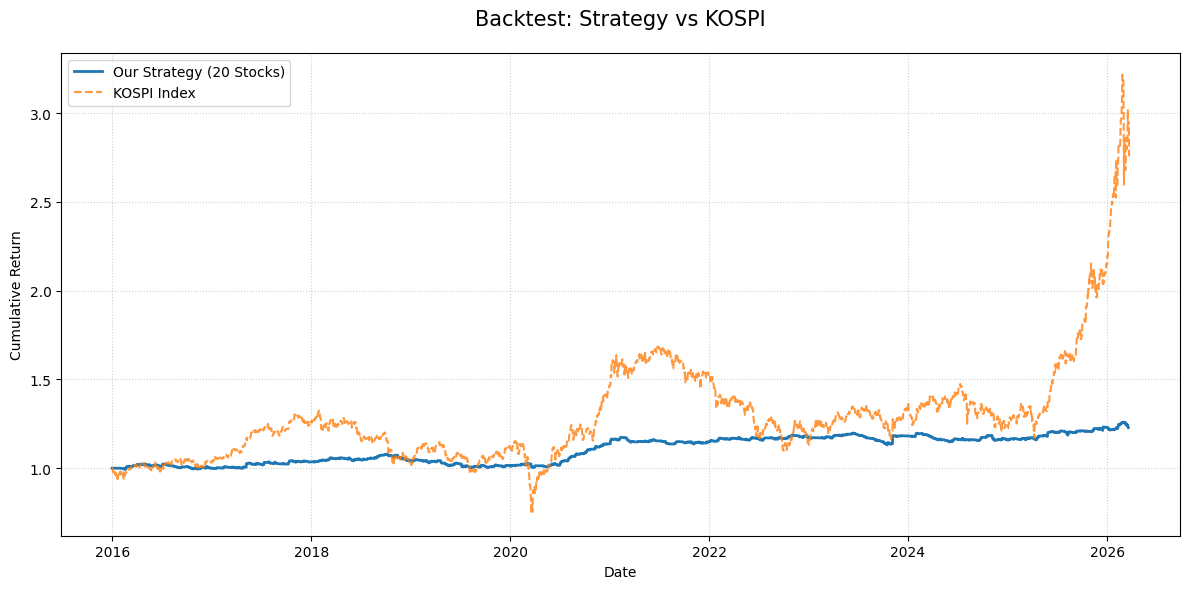

------------------------------
📈 우리 전략 누적 수익률: 22.82%
📉 KOSPI 지수 누적 수익률: 175.62%
🔥 초과 수익률(Alpha): -152.80%p


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import os

# 1. 드라이브 마운트
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. 파일 경로 설정 (동글님 드라이브 목록 기반)
base_path = "/content/drive/MyDrive/"
data_file = os.path.join(base_path, "백테스트_20종목_전체데이터.xlsx")
kospi_file = os.path.join(base_path, "kospi.xlsx")

# 3. 데이터 통합 함수 (엑셀 시트 직접 읽기)
def load_excel_data(file_path):
    # 시트명과 우리 코드에서 쓸 이름 매핑
    sheet_map = {
        '수정주가': 'close',
        '수정고가': 'high',
        '수정저가': 'low',
        '거래량': 'volume',
        '시가총액': 'mcap'
    }

    master = None
    print("📂 엑셀 데이터 로드 중...")

    for s_name, col_key in sheet_map.items():
        # 1행(코드) 헤더로 쓰고, 2~4행(이름 등)은 건너뜁니다.
        df = pd.read_excel(file_path, sheet_name=s_name, header=0, skiprows=[1, 2, 3])
        df.rename(columns={df.columns[0]: 'Date'}, inplace=True)

        # Wide -> Long 변환
        melted = df.melt(id_vars=['Date'], var_name='Code', value_name=col_key)

        if master is None:
            master = melted
        else:
            master = pd.merge(master, melted, on=['Date', 'Code'], how='outer')
        print(f"✅ {s_name} 시트 로드 완료")

    master['Date'] = pd.to_datetime(master['Date'])
    return master

# 4. 백테스트 엔진 (익절 5%, 손절 5일선 이탈)
def run_backtest(df, target_profit=0.05):
    results = []
    print("🔄 전략 시뮬레이션 돌리는 중...")

    for code, group in df.groupby('Code'):
        group = group.sort_values('Date').copy()
        # 숫자 데이터로 변환
        for c in ['close', 'high', 'low', 'volume', 'mcap']:
            group[c] = pd.to_numeric(group[c], errors='coerce')
        group = group.dropna(subset=['close'])

        if len(group) < 15: continue

        # 지표 계산
        group['ma5'] = group['close'].rolling(5).mean()
        low14 = group['low'].rolling(14).min()
        high14 = group['high'].rolling(14).max()
        # Stochastic %K 계산
        k = 100 * ((group['close'] - low14) / (high14 - low14).replace(0, np.nan))
        group['slow_k'] = k.rolling(3).mean()
        group['slow_d'] = group['slow_k'].rolling(3).mean()

        # 신호: 골든크로스 & K<=40 & 가격>MA5
        group['signal'] = (group['slow_k'] > group['slow_d']) & \
                          (group['slow_k'].shift(1) < group['slow_d'].shift(1)) & \
                          (group['slow_k'] <= 40) & (group['close'] > group['ma5'])

        # 매매 시뮬레이션
        in_pos, buy_p = False, 0
        returns = [0.0] * len(group)
        for i in range(1, len(group)):
            if not in_pos:
                if group['signal'].iloc[i-1]: # 신호 다음날 매수
                    in_pos, buy_p = True, group['close'].iloc[i]
            else:
                curr_rtn = (group['close'].iloc[i] / buy_p) - 1
                # 익절 5% 또는 5일선 이탈 시 매도
                if curr_rtn >= target_profit or group['close'].iloc[i] < group['ma5'].iloc[i]:
                    returns[i], in_pos = curr_rtn, False

        group['daily_return'] = returns
        results.append(group[['Date', 'Code', 'daily_return']])

    return pd.concat(results)

# 5. 실행 및 결과 출력
print("-" * 30)
master_data = load_excel_data(data_file)
backtest_res = run_backtest(master_data)

# 수익률 합산
portfolio_rtn = backtest_res.groupby('Date')['daily_return'].mean()
cum_portfolio = (1 + portfolio_rtn).cumprod()

# KOSPI 로드 (에러 방지 강화 버전)
print("📊 KOSPI 벤치마크 비교 중...")
kospi = pd.read_excel(kospi_file)

# 1. 필요한 열만 선택하고 이름 변경 (첫 번째: 날짜, 두 번째: 종가)
kospi = kospi.iloc[:, :2]
kospi.columns = ['Date', 'close']

# 2. 날짜 변환 (핵심: 텍스트는 NaT로 변환하고 삭제)
kospi['Date'] = pd.to_datetime(kospi['Date'], errors='coerce')
kospi = kospi.dropna(subset=['Date'])

# 3. 종가 수치 변환 및 결측치 제거
kospi['close'] = pd.to_numeric(kospi['close'], errors='coerce')
kospi = kospi.dropna(subset=['close'])

# 4. 날짜 기준 정렬 및 인덱스 설정
kospi = kospi.sort_values('Date').set_index('Date')

# 5. KOSPI 누적 수익률 계산
# pct_change() 이후 첫 행은 NaN이므로 0으로 채워 수익률 1부터 시작하게 함
kospi_rtn = kospi['close'].pct_change().fillna(0)
cum_kospi = (1 + kospi_rtn).cumprod()

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(cum_portfolio, label='Our Strategy (20 Stocks)', color='#1f77b4', linewidth=2)
plt.plot(cum_kospi, label='KOSPI Index', color='#ff7f0e', linestyle='--', alpha=0.8)
plt.title('Backtest: Strategy vs KOSPI', fontsize=15, pad=20)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("-" * 30)
if not cum_portfolio.empty and not cum_kospi.empty:
    final_p_rtn = (cum_portfolio.iloc[-1] - 1) * 100
    final_k_rtn = (cum_kospi.iloc[-1] - 1) * 100
    print(f"📈 우리 전략 누적 수익률: {final_p_rtn:.2f}%")
    print(f"📉 KOSPI 지수 누적 수익률: {final_k_rtn:.2f}%")
    print(f"🔥 초과 수익률(Alpha): {final_p_rtn - final_k_rtn:.2f}%p")
else:
    print("수익률 계산에 필요한 데이터가 부족합니다.")

# KOSPI 로드 최종 수정
kospi = pd.read_excel(kospi_file)
# 날짜가 들어있는 행만 찾기 (숫자로 시작하는 데이터만 필터링)
kospi = kospi[kospi.iloc[:, 0].astype(str).str.match(r'\d{4}-\d{2}-\d{2}', na=False)]

kospi['Date'] = pd.to_datetime(kospi.iloc[:, 0])
kospi['close'] = pd.to_numeric(kospi.iloc[:, 1], errors='coerce')
kospi = kospi.sort_values('Date').set_index('Date')
cum_kospi = (1 + kospi['close'].pct_change()).cumprod()

------------------------------
📂 엑셀 데이터 로드 중...
✅ 수정주가 시트 로드 완료
✅ 수정고가 시트 로드 완료
✅ 수정저가 시트 로드 완료
✅ 거래량 시트 로드 완료
✅ 시가총액 시트 로드 완료
🔄 전략 시뮬레이션 돌리는 중...
📊 KOSPI 벤치마크 비교 중...


/tmp/ipykernel_2300/3280725070.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  kospi['Date'] = pd.to_datetime(kospi['Date'], errors='coerce')


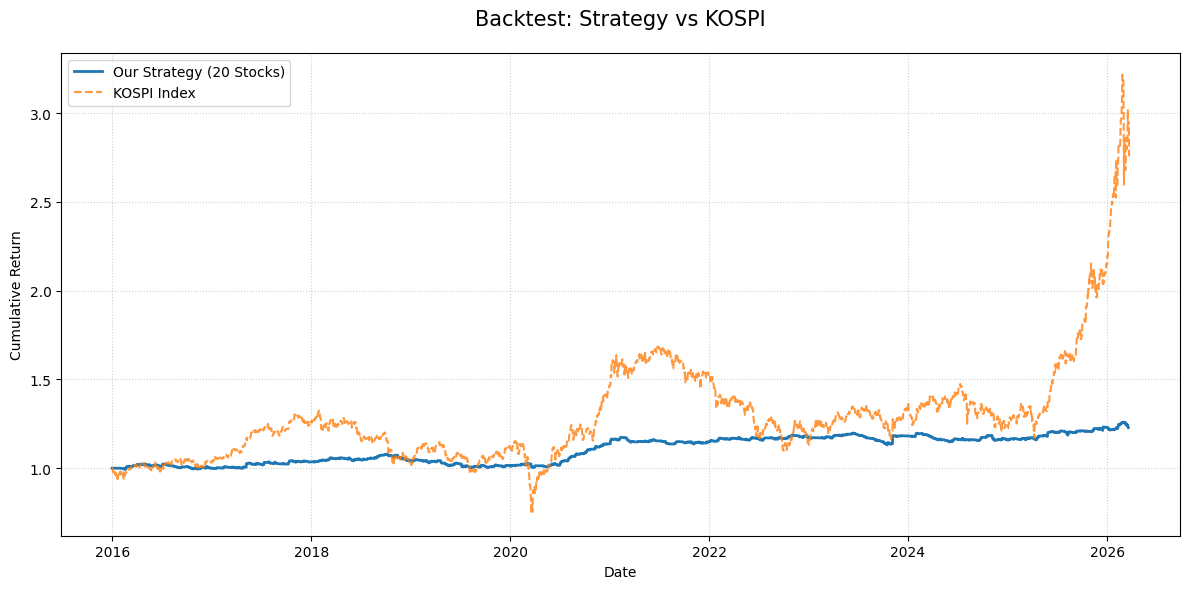

------------------------------
📈 우리 전략 누적 수익률: 22.82%
📉 KOSPI 지수 누적 수익률: 175.62%
🔥 초과 수익률(Alpha): -152.80%p


In [ ]:
# 5. 실행 및 결과 출력
print("-" * 30)
master_data = load_excel_data(data_file)
backtest_res = run_backtest(master_data)

# 수익률 합산
portfolio_rtn = backtest_res.groupby('Date')['daily_return'].mean()
cum_portfolio = (1 + portfolio_rtn).cumprod()

# KOSPI 로드 (에러 방지 강화 버전)
print("📊 KOSPI 벤치마크 비교 중...")
kospi = pd.read_excel(kospi_file)

# 1. 필요한 열만 선택하고 이름 변경 (첫 번째: 날짜, 두 번째: 종가)
kospi = kospi.iloc[:, :2]
kospi.columns = ['Date', 'close']

# 2. 날짜 변환 (핵심: 텍스트는 NaT로 변환하고 삭제)
kospi['Date'] = pd.to_datetime(kospi['Date'], errors='coerce')
kospi = kospi.dropna(subset=['Date'])

# 3. 종가 수치 변환 및 결측치 제거
kospi['close'] = pd.to_numeric(kospi['close'], errors='coerce')
kospi = kospi.dropna(subset=['close'])

# 4. 날짜 기준 정렬 및 인덱스 설정
kospi = kospi.sort_values('Date').set_index('Date')

# 5. KOSPI 누적 수익률 계산
# pct_change() 이후 첫 행은 NaN이므로 0으로 채워 수익률 1부터 시작하게 함
kospi_rtn = kospi['close'].pct_change().fillna(0)
cum_kospi = (1 + kospi_rtn).cumprod()

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(cum_portfolio, label='Our Strategy (20 Stocks)', color='#1f77b4', linewidth=2)
plt.plot(cum_kospi, label='KOSPI Index', color='#ff7f0e', linestyle='--', alpha=0.8)
plt.title('Backtest: Strategy vs KOSPI', fontsize=15, pad=20)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("-" * 30)
if not cum_portfolio.empty and not cum_kospi.empty:
    final_p_rtn = (cum_portfolio.iloc[-1] - 1) * 100
    final_k_rtn = (cum_kospi.iloc[-1] - 1) * 100
    print(f"📈 우리 전략 누적 수익률: {final_p_rtn:.2f}%")
    print(f"📉 KOSPI 지수 누적 수익률: {final_k_rtn:.2f}%")
    print(f"🔥 초과 수익률(Alpha): {final_p_rtn - final_k_rtn:.2f}%p")
else:
    print("수익률 계산에 필요한 데이터가 부족합니다.")

# KOSPI 로드 최종 수정
kospi = pd.read_excel(kospi_file)
# 날짜가 들어있는 행만 찾기 (숫자로 시작하는 데이터만 필터링)
kospi = kospi[kospi.iloc[:, 0].astype(str).str.match(r'\d{4}-\d{2}-\d{2}', na=False)]

kospi['Date'] = pd.to_datetime(kospi.iloc[:, 0])
kospi['close'] = pd.to_numeric(kospi.iloc[:, 1], errors='coerce')
kospi = kospi.sort_values('Date').set_index('Date')
cum_kospi = (1 + kospi['close'].pct_change()).cumprod()

In [ ]:
def calculate_mdd(cum_returns):
    # 누적 최대치 계산
    peak = cum_returns.expanding(min_periods=1).max()
    # 낙폭 계산
    drawdown = (cum_returns - peak) / peak
    return drawdown.min() * 100

strategy_mdd = calculate_mdd(cum_portfolio)
kospi_mdd = calculate_mdd(cum_kospi)

print(f"✅ 우리 전략 MDD: {strategy_mdd:.2f}%")
print(f"✅ 코스피 지수 MDD: {kospi_mdd:.2f}%")

✅ 우리 전략 MDD: -7.04%
✅ 코스피 지수 MDD: -43.90%


In [ ]:
# KOSPI 로드 최종 수정
kospi = pd.read_excel(kospi_file)
# 날짜가 들어있는 행만 찾기 (숫자로 시작하는 데이터만 필터링)
kospi = kospi[kospi.iloc[:, 0].astype(str).str.match(r'\d{4}-\d{2}-\d{2}', na=False)]

kospi['Date'] = pd.to_datetime(kospi.iloc[:, 0])
kospi['close'] = pd.to_numeric(kospi.iloc[:, 1], errors='coerce')
kospi = kospi.sort_values('Date').set_index('Date')
cum_kospi = (1 + kospi['close'].pct_change()).cumprod()

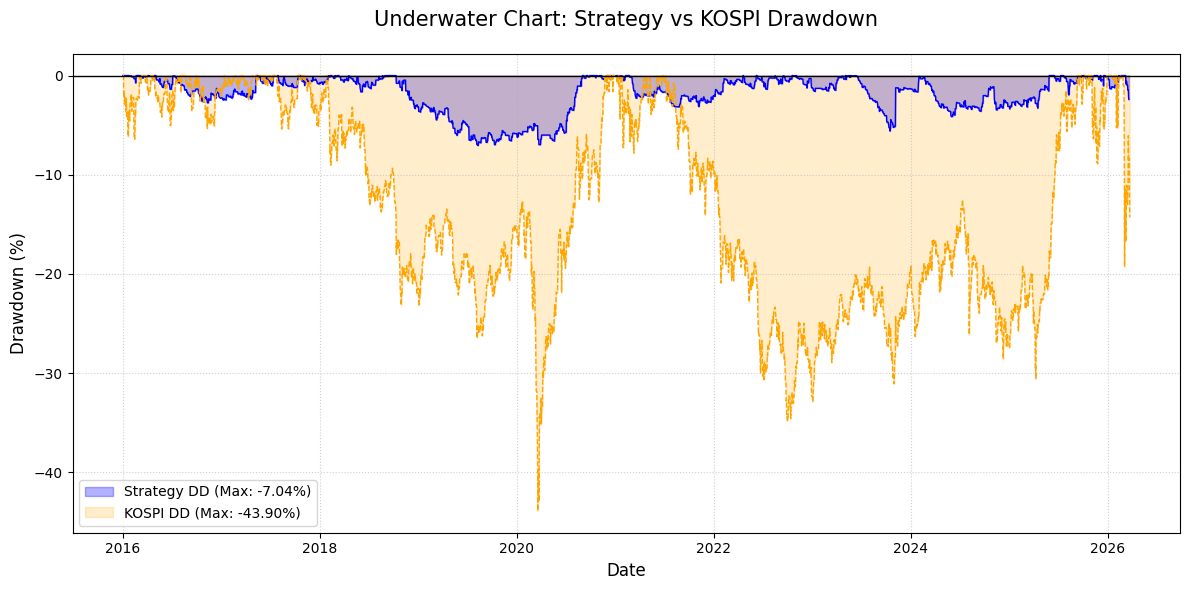

In [ ]:
import matplotlib.pyplot as plt

def plot_drawdown_chart(cum_strategy, cum_kospi):
    # 1. 낙폭(Drawdown) 계산
    # 누적 수익률의 전고점(Peak) 대비 현재 위치 계산
    strat_peak = cum_strategy.expanding(min_periods=1).max()
    strat_dd = (cum_strategy / strat_peak) - 1

    kospi_peak = cum_kospi.expanding(min_periods=1).max()
    kospi_dd = (cum_kospi / kospi_peak) - 1

    # 2. 그래프 그리기
    plt.figure(figsize=(12, 6))

    # 전략 낙폭 영역 (파란색)
    plt.fill_between(strat_dd.index, strat_dd * 100, 0,
                     color='blue', alpha=0.3, label=f'Strategy DD (Max: {strat_dd.min()*100:.2f}%)')
    plt.plot(strat_dd.index, strat_dd * 100, color='blue', linewidth=1)

    # 코스피 낙폭 영역 (주황색)
    plt.fill_between(kospi_dd.index, kospi_dd * 100, 0,
                     color='orange', alpha=0.2, label=f'KOSPI DD (Max: {kospi_dd.min()*100:.2f}%)')
    plt.plot(kospi_dd.index, kospi_dd * 100, color='orange', linewidth=1, linestyle='--')

    # 그래프 서식 설정
    plt.title('Underwater Chart: Strategy vs KOSPI Drawdown', fontsize=15, pad=20)
    plt.ylabel('Drawdown (%)', fontsize=12)
    plt.xlabel('Date', fontsize=12)
    plt.axhline(0, color='black', linewidth=1) # 0선 (해수면)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower left')
    plt.tight_layout()
    plt.show()

# 실행
plot_drawdown_chart(cum_portfolio, cum_kospi)